In [69]:
import numpy as np 
import filter
import matplotlib.pyplot as plt
import importlib
import plant
import filter 
importlib.reload (filter)
importlib.reload (plant)
from plant import w2b_rotation
from madgwick_filter import MadgwickMARG

# Generate input

In [70]:
dt = 0.01
t = np.arange (0, 10, dt)

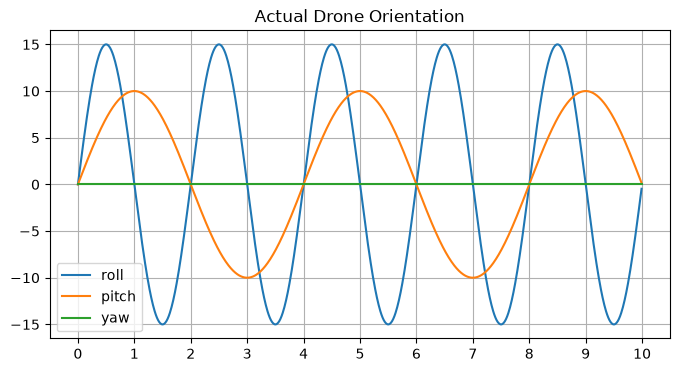

In [71]:
real_roll = np.deg2rad(15) * np.sin (np.pi *t) 
real_pitch = np.deg2rad(10) * np.sin(0.5*np.pi * t)
real_yaw = np.zeros_like (t)

plt.figure(figsize=(8,4))
plt.plot (t, np.rad2deg(real_roll), label = 'roll')
plt.plot (t, np.rad2deg(real_pitch), label = 'pitch')
plt.plot (t, np.rad2deg(real_yaw), label = 'yaw')
plt.grid (True)
plt.xticks(np.arange (0, 11, 1))
plt.title ('Actual Drone Orientation')
plt.legend()
plt.show()

In [72]:
roll_dot = np.gradient(real_roll, dt)
pitch_dot = np.gradient(real_pitch, dt)
yaw_dot = np.gradient(real_yaw, dt)

p = roll_dot - yaw_dot * np.sin(real_pitch)
q = pitch_dot * np.cos(real_roll) + yaw_dot * np.sin(real_roll) * np.cos(real_pitch)
r = -pitch_dot * np.sin(real_roll) + yaw_dot * np.cos(real_roll) * np.cos(real_pitch)

gyro_data = np.array([p, q, r]).T
accel_data = []
mag_data = []
m = np.array([1.0, 0.0, 0.0])
g = np.array([0, 0, 1])

for roll, pitch, yaw in zip (real_roll, real_pitch, real_yaw): 
    R = w2b_rotation(roll, pitch, yaw)
    accel_data.append (R @ g)
    mag_data.append (R @ m)

accel_data = np.array(accel_data)
print (gyro_data.shape)
print (accel_data.shape)

(1000, 3)
(1000, 3)


# Test filter 

In [73]:
quaternions = []
filter = MadgwickMARG()
for gyro, accel, mag in zip (gyro_data, accel_data, mag_data): 
    q = filter.update (gyro, accel, mag, dt)
    quaternions.append (q.copy())
quaternions = np.array(quaternions)

In [74]:
q_norm = np.linalg.norm (quaternions, axis = 1)
print (q_norm.min())
print (q_norm.max())

0.9999999999999998
1.0000000000000002


In [75]:
roll_filtered, pitch_filtered, yaw_filtered = [], [], []
for q in quaternions:
    roll, pitch, yaw = filter.quaternion_to_euler(q)
    roll_filtered.append (roll)
    pitch_filtered.append (pitch)
    yaw_filtered.append (yaw)

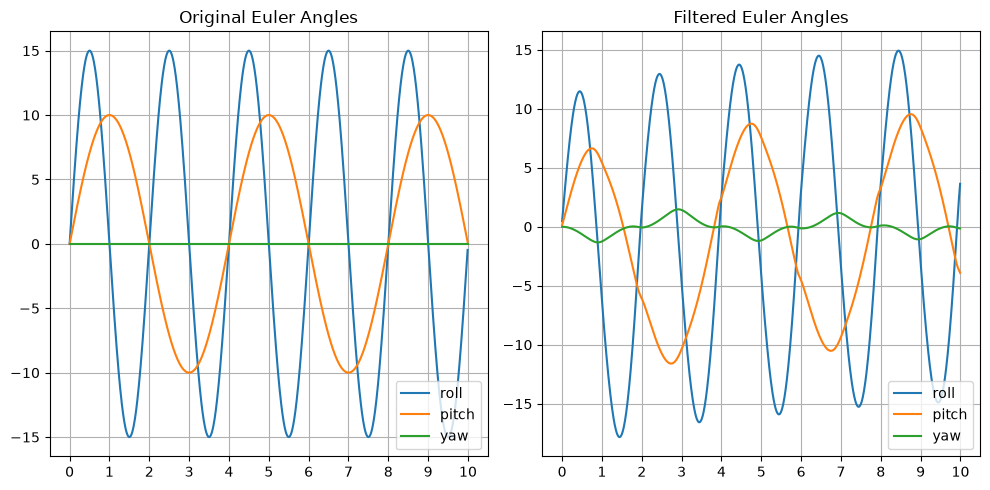

In [76]:
fig, axs = plt.subplots (1, 2, figsize = (10, 5))
axs[0].plot (t, np.rad2deg(real_roll), label = 'roll')
axs[0].plot (t, np.rad2deg(real_pitch), label = 'pitch')
axs[0].plot (t, np.rad2deg(real_yaw), label = 'yaw')
axs[0].set_title ('Original Euler Angles')
axs[0].set_xticks(np.arange (0, 11, 1))
axs[0].legend (loc = 'lower right')
axs[0].grid (True)

axs[1].plot (t, np.rad2deg(roll_filtered), label = 'roll')
axs[1].plot (t, np.rad2deg(pitch_filtered), label = 'pitch')
axs[1].plot (t, np.rad2deg(yaw_filtered), label = 'yaw')
axs[1].set_title ('Filtered Euler Angles')
axs[1].set_xticks (np.arange (0, 11, 1))
axs[1].legend (loc = 'lower right')
axs[1].grid(True)

plt.tight_layout()
plt.show()

* Filtered Euler Angles is similar to original Euler angles 
* Yawing is expected because we don't have magnemometer 

# 